In [ ]:
import csv

# 模拟数据：包含两个特征（Exam1, Exam2）和标签（Pass：1通过，0未通过）
data = [
    ["Exam1", "Exam2", "Pass"],  # 表头
    [34.62366, 78.02469, 0],
    [30.28671, 43.89500, 0],
    [35.84741, 72.90220, 0],
    [60.18260, 86.30855, 1],
    [79.03274, 75.34438, 1],
    [45.08328, 56.31637, 0],
    [61.10666, 96.51143, 1],
    [75.02475, 46.55401, 1],
    [76.09879, 87.42057, 1],
    [84.43282, 43.53339, 1],
    [95.86154, 38.22528, 0],
    [75.01365, 30.60326, 0],
    [82.30705, 76.48196, 1],
    [69.36458, 97.71869, 1],
    [39.53834, 76.03686, 0],
    [53.97105, 89.20734, 1],
    [69.07014, 52.74047, 1],
    [67.94685, 46.67857, 0],
    [70.66151, 92.92714, 1]
]

# 生成 CSV 文件
with open("exam_data.csv", "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerows(data)

print("CSV 文件生成成功！文件名为：exam_data.csv")

In [10]:
import pandas as pd
import numpy as np

# 设置随机种子，保证结果可复现
np.random.seed(42)

# 生成100个样本，分为两类，有明显区分边界
n_samples = 100

# 第一类（Pass=0，未通过）：Exam1和Exam2整体偏低
exam1_fail = np.random.uniform(30, 70, size=int(n_samples*0.5))
exam2_fail = np.random.uniform(30, 60, size=int(n_samples*0.5))

# 第二类（Pass=1，通过）：Exam1和Exam2整体偏高
exam1_pass = np.random.uniform(50, 100, size=int(n_samples*0.5))
exam2_pass = np.random.uniform(50, 100, size=int(n_samples*0.5))

# 合并特征和标签
exam1 = np.concatenate([exam1_fail, exam1_pass])
exam2 = np.concatenate([exam2_fail, exam2_pass])
pass_label = np.concatenate([np.zeros(int(n_samples*0.5)), np.ones(int(n_samples*0.5))])

# 轻微添加噪声（少量样本交叉，更真实）
noise_idx = np.random.choice(n_samples, size=int(n_samples*0.1), replace=False)
pass_label[noise_idx] = 1 - pass_label[noise_idx]

# 整理为DataFrame
data = pd.DataFrame({
    'Exam1': np.round(exam1, 6),
    'Exam2': np.round(exam2, 6),
    'Pass': pass_label.astype(int)
})

# 保存为CSV
data.to_csv('exam_train_data.csv', index=False)
print(f"生成{len(data)}条数据，已保存为 exam_classified_data.csv")

生成100条数据，已保存为 exam_classified_data.csv


In [11]:
import numpy as np
import pandas as pd

# 设置随机种子，保证结果可复现
np.random.seed(42)

# 生成100个样本
n_samples = 100

# 生成特征数据（在0-100范围内）
exam1 = np.random.uniform(0, 100, n_samples)
exam2 = np.random.uniform(0, 100, n_samples)

# 定义二次曲线决策边界：(x/50)^2 + (y/50)^2 = 2（椭圆边界）
# 内侧为类别0，外侧为类别1（可根据实际需求调整）
boundary = (exam1 / 50) ** 2 + (exam2 / 50) ** 2
labels = (boundary > 2).astype(int)  # 边界外侧为1，内侧为0

# 添加少量噪声，使数据更接近真实场景
noise = np.random.normal(0, 0.3, n_samples)
labels = ((boundary + noise) > 2).astype(int)

# 创建DataFrame
data = pd.DataFrame({
    'Exam1': exam1.round(2),
    'Exam2': exam2.round(2),
    'Pass': labels
})

# 保存为CSV文件
data.to_csv('train_data.csv', index=False)

print("数据分布说明：")
print(f"类别0（未通过）样本数：{sum(data['Pass'] == 0)}")
print(f"类别1（通过）样本数：{sum(data['Pass'] == 1)}")

数据分布说明：
类别0（未通过）样本数：43
类别1（通过）样本数：57


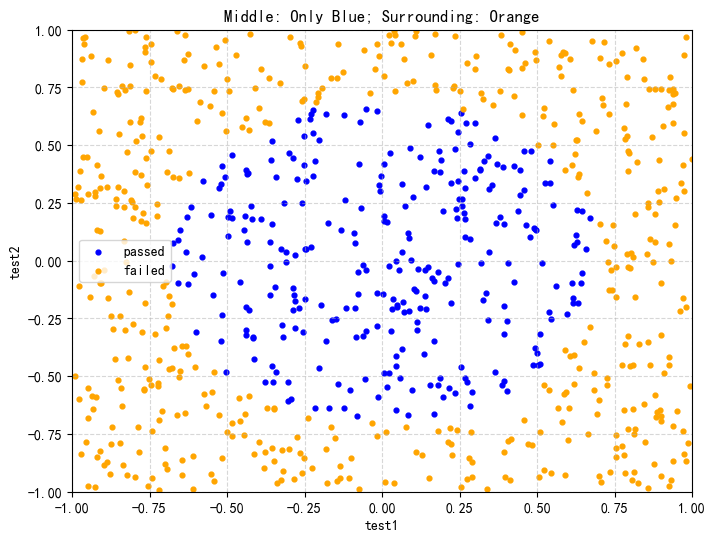

数据前5行：
      test1     test2  pass
0 -0.250920  0.414477     1
1  0.901429 -0.694922     0
2  0.463988  0.152577     1
3  0.197317  0.213430     1
4 -0.687963 -0.151739     0


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1. 生成数据（中间全蓝色，外围黄色） ----------
np.random.seed(42)
n_samples = 800  # 大样本量，确保中间蓝色区域密集无空隙
noise_ratio = 0  # 无噪声，边界绝对清晰

# 生成test1和test2（范围[-1,1]）
test1 = np.random.uniform(-1, 1, n_samples)
test2 = np.random.uniform(-1, 1, n_samples)

# 计算点到原点的距离
distance = np.sqrt(test1**2 + test2**2)

# 核心逻辑：距离原点 < 0.7 的中间区域 → 全为蓝色（passed=1）
# 距离原点 ≥ 0.7 的外围区域 → 黄色（failed=0）
pass_label = np.where(distance < 0.7, 1, 0)

# 构造DataFrame
data = pd.DataFrame({
    "test1": test1,
    "test2": test2,
    "pass": pass_label
})

# ---------- 2. 保存为CSV ----------
data.to_csv("chip_test.csv", index=False)

# ---------- 3. 可视化验证（中间全蓝，外围黄） ----------
plt.figure(figsize=(8, 6))
passed = data[data["pass"] == 1]  # 中间蓝色
failed = data[data["pass"] == 0]  # 外围黄色

# 绘制点（蓝色填充中间，黄色仅在外围）
plt.scatter(passed["test1"], passed["test2"], color="blue", label="passed", s=12)  # 小点更密集
plt.scatter(failed["test1"], failed["test2"], color="orange", label="failed", s=12)

plt.xlabel("test1")
plt.ylabel("test2")
plt.title("Middle: Only Blue; Surrounding: Orange")
plt.legend()
plt.grid(linestyle="--", alpha=0.5)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.show()

# 打印前5行数据
print("数据前5行：")
print(data.head())

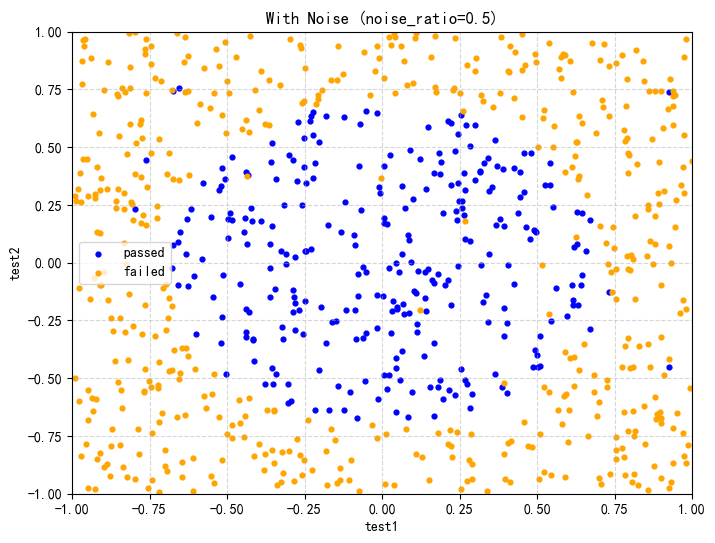

数据前5行：
      test1     test2  pass
0 -0.250920  0.414477     1
1  0.901429 -0.694922     0
2  0.463988  0.152577     1
3  0.197317  0.213430     1
4 -0.687963 -0.151739     0


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # 固定随机种子，确保结果可复现
n_samples = 800     # 样本量
noise_ratio = 0.02   # 50% 噪点（测试用，实际建议0.02~0.05）

# 生成特征
test1 = np.random.uniform(-1, 1, n_samples)
test2 = np.random.uniform(-1, 1, n_samples)

# 计算到原点的距离
distance = np.sqrt(test1**2 + test2**2)

# 基础分类：中间蓝色（distance < 0.7），外围黄色（distance ≥ 0.7）
pass_label = np.where(distance < 0.7, 1, 0)

# --------------------------
# 关键：添加噪点（随机翻转标签）
# --------------------------
if noise_ratio > 0:
    # 随机选择要翻转的样本索引
    noise_indices = np.random.choice(
        n_samples, 
        size=int(n_samples * noise_ratio),  # 翻转的样本数量=总样本×噪点比例
        replace=False  # 不重复选择同一样本
    )
    # 翻转标签（1→0，0→1）
    pass_label[noise_indices] = 1 - pass_label[noise_indices]

# 构造数据框
data = pd.DataFrame({
    "test1": test1,
    "test2": test2,
    "pass": pass_label
})

# 保存CSV
data.to_csv("chip_test_with_noise.csv", index=False)

# 可视化
plt.figure(figsize=(8, 6))
passed = data[data["pass"] == 1]
failed = data[data["pass"] == 0]

plt.scatter(passed["test1"], passed["test2"], color="blue", label="passed", s=12)
plt.scatter(failed["test1"], failed["test2"], color="orange", label="failed", s=12)

plt.xlabel("test1")
plt.ylabel("test2")
plt.title("With Noise (noise_ratio=0.5)")
plt.legend()
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid(linestyle="--", alpha=0.5)
plt.show()

# 打印前5行
print("数据前5行：")
print(data.head())